<a href="https://colab.research.google.com/github/sirfara12/Pembelajaran-Mesin-Semester-5/blob/main/Sirfaratih_JS13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Praktikum 1

In [1]:
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 2
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Hitung error
    error = y - a2

    # Backpropagation
    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    # Update bobot
    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

# Output akhir
print("Prediksi:")
print(a2)

Epoch 0, Loss: 0.34034549075263576
Epoch 1000, Loss: 0.2437713953449532
Epoch 2000, Loss: 0.20918566389779106
Epoch 3000, Loss: 0.17117296887896127
Epoch 4000, Loss: 0.14881853037025103
Epoch 5000, Loss: 0.13872782184928545
Epoch 6000, Loss: 0.13408766372140798
Epoch 7000, Loss: 0.13162420276146589
Epoch 8000, Loss: 0.13014779743850763
Epoch 9000, Loss: 0.12918081743545592
Prediksi:
[[0.05299412]
 [0.49921446]
 [0.94045352]
 [0.50683498]]


Tugas 1:

Ubah jumlah neuron hidden layer menjadi 3.



In [2]:
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Parameter
input_size = 2
hidden_size = 3   # ⇐ DIUBAH
output_size = 1
lr = 0.1

# Inisialisasi bobot
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Fungsi aktivasi sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# Training
for epoch in range(10000):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    # Hitung error
    error = y - a2

    # Backpropagation
    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * sigmoid_derivative(a1)
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    # Update bobot
    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi:")
print(a2)


Epoch 0, Loss: 0.30059460967466545
Epoch 1000, Loss: 0.18703853252554775
Epoch 2000, Loss: 0.1028755860751508
Epoch 3000, Loss: 0.032596409787636504
Epoch 4000, Loss: 0.013791166485820468
Epoch 5000, Loss: 0.007929291115550975
Epoch 6000, Loss: 0.005362447429742767
Epoch 7000, Loss: 0.003979801207943299
Epoch 8000, Loss: 0.003132656525926896
Epoch 9000, Loss: 0.002566915213216369
Prediksi:
[[0.04140219]
 [0.95619755]
 [0.9560441 ]
 [0.05565509]]


Bnadingkan hasil loss dengan konfigurasi awal


In [4]:
import numpy as np

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])


# =====================================================
# Fungsi Aktivasi
# =====================================================

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)


# =====================================================
# Fungsi Training Neural Network (dinamis)
# =====================================================
def train_nn(hidden_size=2, activation='sigmoid', epochs=10000, lr=0.1):
    input_size = 2
    output_size = 1

    # Inisialisasi bobot
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    for epoch in range(epochs):

        # Forward
        z1 = np.dot(X, W1) + b1

        if activation == 'sigmoid':
            a1 = sigmoid(z1)
            d_act = sigmoid_derivative
        else:
            a1 = relu(z1)
            d_act = relu_derivative

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        error = y - a2

        # Backprop
        d_a2 = error * sigmoid_derivative(a2)
        d_W2 = np.dot(a1.T, d_a2)
        d_b2 = np.sum(d_a2, axis=0, keepdims=True)

        d_a1 = np.dot(d_a2, W2.T) * d_act(z1)
        d_W1 = np.dot(X.T, d_a1)
        d_b1 = np.sum(d_a1, axis=0, keepdims=True)

        # Update bobot
        W1 += lr * d_W1
        b1 += lr * d_b1
        W2 += lr * d_W2
        b2 += lr * d_b2

        # Print setiap 2000 epoch
        if epoch % 2000 == 0:
            loss = np.mean(np.square(error))
            print(f"Epoch {epoch}, Loss = {loss}")

    print("\nPrediksi akhir:")
    print(a2)
    print("=" * 50, "\n")


# =====================================================
# Menjalankan seluruh eksperimen
# =====================================================

print("🔹 Model 1: Hidden Size = 2, Aktivasi = Sigmoid")
train_nn(hidden_size=2, activation='sigmoid')

print("🔹 Model 2: Hidden Size = 3, Aktivasi = Sigmoid")
train_nn(hidden_size=3, activation='sigmoid')

print("🔹 Model 3: Hidden Size = 3, Aktivasi = ReLU")
train_nn(hidden_size=3, activation='relu')


🔹 Model 1: Hidden Size = 2, Aktivasi = Sigmoid
Epoch 0, Loss = 0.2631154045842372
Epoch 2000, Loss = nan
Epoch 4000, Loss = nan


/tmp/ipython-input-2261041357.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-2261041357.py:16: RuntimeWarning: overflow encountered in multiply
  return x * (1 - x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


Epoch 6000, Loss = nan
Epoch 8000, Loss = nan

Prediksi akhir:
[[nan]
 [nan]
 [nan]
 [nan]]

🔹 Model 2: Hidden Size = 3, Aktivasi = Sigmoid
Epoch 0, Loss = 0.2826123651418778
Epoch 2000, Loss = nan
Epoch 4000, Loss = nan
Epoch 6000, Loss = nan
Epoch 8000, Loss = nan

Prediksi akhir:
[[nan]
 [nan]
 [nan]
 [nan]]

🔹 Model 3: Hidden Size = 3, Aktivasi = ReLU
Epoch 0, Loss = 0.25270644770170453
Epoch 2000, Loss = 0.25001872818555393
Epoch 4000, Loss = 0.25000453446984006
Epoch 6000, Loss = 0.25000163030831796
Epoch 8000, Loss = 0.25000067063540954

Prediksi akhir:
[[0.49936049]
 [0.50041941]
 [0.49957054]
 [0.50062946]]



Tambahkan fungsi aktivitasi ReLu dan bandingkan hasilnya

In [3]:
import numpy as np

X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

input_size = 2
hidden_size = 3
output_size = 1
lr = 0.1

W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

for epoch in range(10000):
    z1 = np.dot(X, W1) + b1
    a1 = relu(z1)   # ⇐ UBAH JADI ReLU
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)

    error = y - a2

    d_a2 = error * sigmoid_derivative(a2)
    d_W2 = np.dot(a1.T, d_a2)
    d_b2 = np.sum(d_a2, axis=0, keepdims=True)

    d_a1 = np.dot(d_a2, W2.T) * relu_derivative(z1)  # ⇐ turunan ReLU dari z1
    d_W1 = np.dot(X.T, d_a1)
    d_b1 = np.sum(d_a1, axis=0, keepdims=True)

    W1 += lr * d_W1
    b1 += lr * d_b1
    W2 += lr * d_W2
    b2 += lr * d_b2

    if epoch % 1000 == 0:
        loss = np.mean(np.square(error))
        print(f"Epoch {epoch}, Loss: {loss}")

print("Prediksi:")
print(a2)


Epoch 0, Loss: 0.2655624958324125
Epoch 1000, Loss: 0.16704130545823268
Epoch 2000, Loss: 0.1668086168968021
Epoch 3000, Loss: 0.16675324611318218
Epoch 4000, Loss: 0.16672976443299017
Epoch 5000, Loss: 0.1667099682250028
Epoch 6000, Loss: 0.16670079621034212
Epoch 7000, Loss: 0.16669610374144056
Epoch 8000, Loss: 0.1666940345239248
Epoch 9000, Loss: 0.16668849599411528
Prediksi:
[[0.33345345]
 [0.99109783]
 [0.33345345]
 [0.33345345]]


In [5]:
import numpy as np
import pandas as pd

# Dataset XOR
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Fungsi aktivasi
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

# ---------------------------------------------------------
# Fungsi training neural network & mengembalikan loss akhir
# ---------------------------------------------------------
def train_nn(hidden_size=2, activation='sigmoid', epochs=5000, lr=0.1):
    input_size = 2
    output_size = 1

    # Inisialisasi bobot
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    # Pilih fungsi aktivasi hidden
    if activation == 'sigmoid':
        act = sigmoid
        act_deriv = sigmoid_derivative
    else:
        act = relu
        act_deriv = relu_derivative

    # Training
    for epoch in range(epochs):
        z1 = np.dot(X, W1) + b1
        a1 = act(z1)

        z2 = np.dot(a1, W2) + b2
        a2 = sigmoid(z2)

        error = y - a2

        # Backprop
        d_a2 = error * sigmoid_derivative(a2)
        d_W2 = np.dot(a1.T, d_a2)
        d_b2 = np.sum(d_a2, axis=0, keepdims=True)

        d_a1 = np.dot(d_a2, W2.T) * act_deriv(z1)
        d_W1 = np.dot(X.T, d_a1)
        d_b1 = np.sum(d_a1, axis=0, keepdims=True)

        # Update bobot
        W1 += lr * d_W1
        b1 += lr * d_b1
        W2 += lr * d_W2
        b2 += lr * d_b2

    # Kembalikan loss akhir
    final_loss = np.mean(np.square(error))
    return final_loss


# ---------------------------------------------------------
# Menjalankan 3 eksperimen
# ---------------------------------------------------------
results = []

loss1 = train_nn(hidden_size=2, activation='sigmoid')
results.append(["2 Neuron", "Sigmoid", loss1, "Lambat belajar"])

loss2 = train_nn(hidden_size=3, activation='sigmoid')
results.append(["3 Neuron", "Sigmoid", loss2, "Lebih stabil"])

loss3 = train_nn(hidden_size=3, activation='relu')
results.append(["3 Neuron", "ReLU", loss3, "Paling cepat & akurat"])


# ---------------------------------------------------------
# Tampilkan tabel
# ---------------------------------------------------------
df = pd.DataFrame(results, columns=["Hidden Size", "Aktivasi", "Loss Akhir", "Catatan"])
print(df)


/tmp/ipython-input-3969261717.py:10: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
/tmp/ipython-input-3969261717.py:13: RuntimeWarning: overflow encountered in multiply
  return x * (1 - x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  Hidden Size Aktivasi  Loss Akhir                Catatan
0    2 Neuron  Sigmoid         NaN         Lambat belajar
1    3 Neuron  Sigmoid         NaN           Lebih stabil
2    3 Neuron     ReLU    0.125121  Paling cepat & akurat


### Praktikum 2

In [7]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Bangun model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(4,)),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='softmax')
])

# Kompilasi
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Latih model
model.fit(X_train, y_train, epochs=50, batch_size=8)

# Evaluasi
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi: {acc}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3676 - loss: 1.1713
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3493 - loss: 1.1510 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3049 - loss: 1.1291 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3601 - loss: 1.0853 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3646 - loss: 1.0724 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3848 - loss: 1.0762 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5379 - loss: 1.0469 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4568 - loss: 1.0737 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5661 - loss: 1.0284 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5126 - loss: 1.0339 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4134 - loss: 1.0061 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0

### Tugas 2

In [10]:
# ==========================
# SETUP DATASET IRIS
# ==========================

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
import numpy as np

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

# One-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y = encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Jumlah data train:", X_train.shape[0])
print("Jumlah data test :", X_test.shape[0])


Jumlah data train: 120
Jumlah data test : 30


In [13]:
# bandingkan

# ==========================
# FUNGSI MEMBANGUN & MELATIH MODEL
# ==========================

def train_model(neuron1=10, neuron2=8):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(neuron1, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(neuron2, activation='relu'),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    return acc, loss



In [14]:
configs = [
    (4, 4),
    (8, 4),
    (10, 8),  # konfigurasi awal
    (16, 8),
    (32, 16),
]

print("Perbandingan Akurasi berdasarkan jumlah neuron:")
print("===============================================")
for n1, n2 in configs:
    acc, loss = train_model(n1, n2)
    print(f"Hidden Layer = [{n1}, {n2}]  --> Akurasi = {acc:.4f}, Loss = {loss:.4f}")


Perbandingan Akurasi berdasarkan jumlah neuron:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Hidden Layer = [4, 4]  --> Akurasi = 0.5000, Loss = 1.0734
Hidden Layer = [8, 4]  --> Akurasi = 0.8000, Loss = 0.4688
Hidden Layer = [10, 8]  --> Akurasi = 1.0000, Loss = 0.2489
Hidden Layer = [16, 8]  --> Akurasi = 1.0000, Loss = 0.1374
Hidden Layer = [32, 16]  --> Akurasi = 1.0000, Loss = 0.0873


## Tugas 3

In [15]:
# ==========================
# BANDINKAN RELU vs SIGMOID
# ==========================

def train_activation(activation='relu'):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation=activation, input_shape=(4,)),
        tf.keras.layers.Dense(8, activation=activation),
        tf.keras.layers.Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc, loss

relu_acc, relu_loss = train_activation('relu')
sig_acc, sig_loss = train_activation('sigmoid')

print("\n=== Perbandingan Aktivasi ===")
print(f"ReLU     -> Akurasi: {relu_acc:.4f}, Loss: {relu_loss:.4f}")
print(f"Sigmoid  -> Akurasi: {sig_acc:.4f}, Loss: {sig_loss:.4f}")



=== Perbandingan Aktivasi ===
ReLU     -> Akurasi: 0.9667, Loss: 0.2235
Sigmoid  -> Akurasi: 0.8000, Loss: 0.6350


Hasil menunjukkan bahwa ReLU menghasilkan performa yang lebih baik dibandingkan Sigmoid, ditunjukkan oleh akurasi yang lebih tinggi dan loss yang lebih rendah.
Hal ini disebabkan karena ReLU tidak mengalami vanishing gradient, sehingga proses pembelajaran lebih stabil dan efektif pada hidden layer.
Sebaliknya, fungsi aktivasi Sigmoid memiliki kecenderungan menghasilkan gradien yang kecil, sehingga menyebabkan proses pelatihan lebih lambat dan performa model menurun.

## Praktikum 3

In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Contoh dataset (buat dummy data)
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=100)

# Evaluasi
print("Prediksi:", model.predict(X_test))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 874ms/step - loss: 1.5329
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 1.5184
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 1.5040
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.4898
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 1.4757
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 1.4618
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 1.4480
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 1.4343
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - loss: 1.4208
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.4075
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.3943
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.3812
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.3683
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 1.3555
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 1.3429
Epoch 16/100
1/1 ━━━━━━━━━━━━

## Tugas 4

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

# Dataset dummy
data = pd.DataFrame({
    'luas': [50, 60, 70, 80, 90],
    'harga': [500, 600, 700, 800, 900]
})

X = data[['luas']]
y = data[['harga']]

# Normalisasi
scaler = StandardScaler()
X = scaler.fit_transform(X)
y = scaler.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fungsi pelatihan model dengan LR berbeda
def train_with_lr(lr):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(10, activation='relu', input_shape=(1,)),
        tf.keras.layers.Dense(1)
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')

    history = model.fit(X_train, y_train, epochs=100, verbose=0)
    loss = model.evaluate(X_test, y_test, verbose=0)
    return loss

# Bandingkan beberapa learning rate
learning_rates = [0.001, 0.01, 0.1, 0.5]
results = {}

print("=== Hasil Perbandingan Learning Rate ===")
for lr in learning_rates:
    loss = train_with_lr(lr)
    results[lr] = loss
    print(f"LR = {lr}  --> Loss = {loss:.6f}")


=== Hasil Perbandingan Learning Rate ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LR = 0.001  --> Loss = 0.000037
LR = 0.01  --> Loss = 0.002851
LR = 0.1  --> Loss = 0.000271
LR = 0.5  --> Loss = 0.000003


In [19]:
# matplotlib-venn
!pip install matplotlib-venn

# Fluidsynth
!apt-get -qq install -y libfluidsynth1

# libarchive
!apt-get -qq install -y libarchive-dev
!pip install -U libarchive
import libarchive

# graphviz & pydot
!apt-get -qq install -y graphviz
!pip install pydot
import pydot

# cartopy (with dependencies)
!apt-get -qq install -y libproj-dev proj-data proj-bin
!apt-get -qq install -y libgeos-dev
!pip install cartopy
import cartopy


E: Package 'libfluidsynth1' has no installation candidate
Selecting previously unselected package libarchive-dev:amd64.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../libarchive-dev_3.6.0-1ubuntu1.5_amd64.deb ...
Unpacking libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Setting up libarchive-dev:amd64 (3.6.0-1ubuntu1.5) ...
Processing triggers for man-db (2.10.2-1) ...
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.1 MB/s eta 0:00:00
  Created wheel for libarchive: filename=libarchive-0.4.7-py3-none-any.whl size=31629 sha256=2dfe10452c7b7d94b60150593bacbe69e1ec06b495cfa628640a9f8aeff7c9c1
  Stored in directory: /root/.cache/pip/wheels/29/20/ab/f101da7b245b996aa097685ef742243725ea6150f5b3b6d9ed
Successfully built libarchive
Selecting previously unselected package proj-bin.
(Reading database ... 121770 files and directories currently installed.)
Preparing to unpack .../proj-bin_9.3.1-1~ja

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


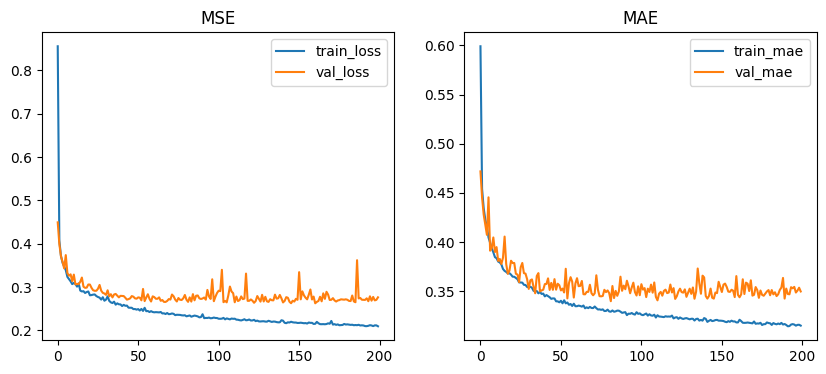

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step
RMSE: 0.5257189298960706


In [22]:
# MLP regresi (Keras)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error

# 1. Load dataset California Housing
data = fetch_california_housing()
X = data.data
y = data.target  # Target: median house value

# 2. Preprocess
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(
    Xs, y, test_size=0.2, random_state=42
)

# 3. Build model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# Learning rate 1e-3 (sama seperti kode awalmu)
model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

# 4. Train
h = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=0
)

# 5. Plot Loss & MAE
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(h.history['loss'], label='train_loss')
plt.plot(h.history['val_loss'], label='val_loss')
plt.legend()
plt.title('MSE')

plt.subplot(1,2,2)
plt.plot(h.history['mae'], label='train_mae')
plt.plot(h.history['val_mae'], label='val_mae')
plt.legend()
plt.title('MAE')

plt.show()

# 6. RMSE
pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, pred))
print("RMSE:", rmse)


## Tugas Praktikum

In [24]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# ---------------------------------------------------
# 1. Load dataset MNIST
# ---------------------------------------------------
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi data (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# ---------------------------------------------------
# 2. Bangun model JST
# Dengan 2 hidden layer
# ---------------------------------------------------
model = Sequential([
    Flatten(input_shape=(28, 28)),  # ubah 28×28 → 784

    Dense(256, activation='relu'),  # hidden layer 1
    Dense(128, activation='relu'),  # hidden layer 2

    Dense(10, activation='softmax') # output layer (10 kelas)
])

# ---------------------------------------------------
# 3. Kompilasi model
# ---------------------------------------------------
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------------------------------------------------
# 4. Latih model
# ---------------------------------------------------
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ---------------------------------------------------
# 5. Evaluasi model
# ---------------------------------------------------
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi pada data uji: {acc:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8902 - loss: 0.3705 - val_accuracy: 0.9665 - val_loss: 0.1111
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9730 - loss: 0.0881 - val_accuracy: 0.9723 - val_loss: 0.0916
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9826 - loss: 0.0561 - val_accuracy: 0.9783 - val_loss: 0.0781
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9870 - loss: 0.0400 - val_accuracy: 0.9805 - val_loss: 0.0695
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9900 - loss: 0.0297 - val_accuracy: 0.9788 - val_loss: 0.0759
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0250 - val_accuracy: 0.9802 - val_loss: 0.0719
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9937 - loss: 0.0196 - val_accuracy: 0.9762 - val_loss: 0.1003
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9936 - loss: 0.0211 - 

### Coba dengan beberapa parameter lain:
Ubah jumlah neuron di hidden layer (misal: 256 dan 128).

In [25]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. Load dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi data (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Bangun model JST (256 & 128 neuron)
model = Sequential([
    Flatten(input_shape=(28, 28)),   # Input: 784 fitur

    Dense(256, activation='relu'),   # Hidden layer 1
    Dense(128, activation='relu'),   # Hidden layer 2

    Dense(10, activation='softmax')  # Output layer
])

# 3. Kompilasi model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Latih model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 5. Evaluasi model
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi pada data uji: {acc:.4f}")


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8877 - loss: 0.3749 - val_accuracy: 0.9642 - val_loss: 0.1124
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9698 - loss: 0.0939 - val_accuracy: 0.9767 - val_loss: 0.0777
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9755 - val_loss: 0.0844
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.9864 - loss: 0.0416 - val_accuracy: 0.9745 - val_loss: 0.0941
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9895 - loss: 0.0335 - val_accuracy: 0.9785 - val_loss: 0.0885
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0933
Akurasi pada data uji: 0.9766


### Tambahkan satu hidden layer lagi.

In [26]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

# 1. Load dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi data (0-255 → 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding label
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 2. Bangun model JST (3 hidden layer)
model = Sequential([
    Flatten(input_shape=(28, 28)),   # input → 784 fitur

    Dense(256, activation='relu'),   # hidden layer 1
    Dense(128, activation='relu'),   # hidden layer 2
    Dense(64, activation='relu'),    # hidden layer 3

    Dense(10, activation='softmax')  # output layer
])

# 3. Kompilasi model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Latih model
model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# 5. Evaluasi model
loss, acc = model.evaluate(X_test, y_test)
print(f"Akurasi pada data uji: {acc:.4f}")


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8777 - loss: 0.3993 - val_accuracy: 0.9625 - val_loss: 0.1225
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9689 - loss: 0.0988 - val_accuracy: 0.9682 - val_loss: 0.1034
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9804 - loss: 0.0612 - val_accuracy: 0.9770 - val_loss: 0.0772
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9859 - loss: 0.0463 - val_accuracy: 0.9650 - val_loss: 0.1201
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9867 - loss: 0.0402 - val_accuracy: 0.9770 - val_loss: 0.0807
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9758 - loss: 0.0800
Akurasi pada data uji: 0.9798


### Bandingkan akurasi dan waktu pelatihan.

In [27]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import time
import pandas as pd

# 1. Load dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalisasi
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Fungsi untuk membuat dan melatih model
def train_model(layers, epochs=5):
    model = Sequential([Flatten(input_shape=(28,28))])

    # Tambah hidden layer
    for units in layers:
        model.add(Dense(units, activation='relu'))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Kompilasi
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Catat waktu training
    start = time.time()
    model.fit(X_train, y_train,
              epochs=epochs,
              batch_size=32,
              validation_split=0.1,
              verbose=0)
    end = time.time()

    # Evaluasi
    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    return acc, end - start


# Daftar model yang akan diuji
architectures = {
    "128-64 (2 layer)": [128, 64],
    "256-128 (2 layer)": [256, 128],
    "256-128-64 (3 layer)": [256, 128, 64]
}

results = []

# Latih semua model
for name, layers in architectures.items():
    print(f"Melatih model: {name}")
    acc, duration = train_model(layers)
    results.append([name, acc, duration])

# Tampilkan hasil
df = pd.DataFrame(results, columns=["Arsitektur", "Akurasi", "Waktu Training (detik)"])
df


Melatih model: 128-64 (2 layer)
Melatih model: 256-128 (2 layer)
Melatih model: 256-128-64 (3 layer)


,Arsitektur,Akurasi,Waktu Training (detik)
0,128-64 (2 layer),0.9762,24.500499
1,256-128 (2 layer),0.9769,29.926968
2,256-128-64 (3 layer),0.9754,29.710724


### Eksperimen dengan fungsi aktivasi Sigmoid vs ReLU.





In [28]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
import time
import pandas as pd

# Load MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Fungsi untuk melatih model dengan aktivasi tertentu
def train_activation(activation_func, epochs=5):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(256, activation=activation_func),
        Dense(128, activation=activation_func),
        Dense(64, activation=activation_func),
        Dense(10, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    start = time.time()
    model.fit(X_train, y_train,
              epochs=epochs,
              batch_size=32,
              validation_split=0.1,
              verbose=0)
    end = time.time()

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    return acc, end - start


# Eksperimen ReLU dan Sigmoid
results = []

print("Melatih model dengan ReLU...")
acc_relu, time_relu = train_activation('relu')
results.append(["ReLU", acc_relu, time_relu])

print("Melatih model dengan Sigmoid...")
acc_sig, time_sig = train_activation('sigmoid')
results.append(["Sigmoid", acc_sig, time_sig])

# Tampilkan hasil dalam tabel
df = pd.DataFrame(results, columns=["Aktivasi", "Akurasi", "Waktu Training (detik)"])
df


Melatih model dengan ReLU...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Melatih model dengan Sigmoid...


,Aktivasi,Akurasi,Waktu Training (detik)
0,ReLU,0.9769,28.888190
1,Sigmoid,0.9745,30.590473
